In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
df = pd.read_csv(r"Downloads\StudentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [9]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [10]:
df = df.dropna()

In [12]:
le = LabelEncoder()

In [13]:
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [14]:
X = df.drop("math score", axis=1)
y = df["math score"]

In [15]:
print(X)

     gender  race/ethnicity  parental level of education  lunch  \
0         0               1                            1      1   
1         0               2                            4      1   
2         0               1                            3      1   
3         1               0                            0      0   
4         1               2                            4      1   
..      ...             ...                          ...    ...   
995       0               4                            3      1   
996       1               2                            2      0   
997       0               2                            2      0   
998       0               3                            4      1   
999       0               3                            4      0   

     test preparation course  reading score  writing score  
0                          1             72             74  
1                          0             90             88  
2           

In [16]:
print(y)

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [20]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [21]:
y_pred = model.predict(X_test_poly)

In [22]:
print("Training MSE:", mean_squared_error(y_train, model.predict(X_train_poly)))
print("Testing MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Training MSE: 28.564049017475966
Testing MSE: 31.81380054199456
R2 Score: 0.8692610761721349


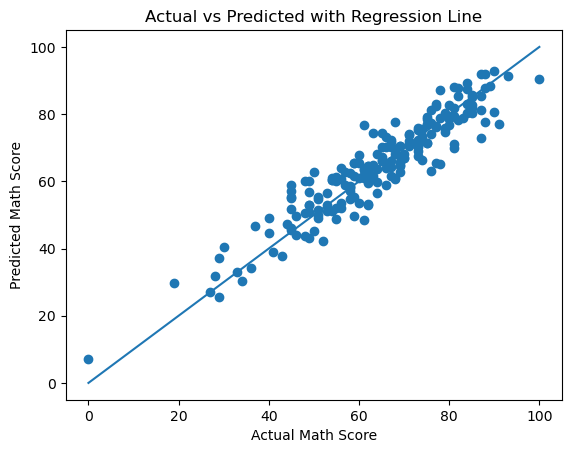

In [32]:
plt.figure()
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted with Regression Line")
plt.show()

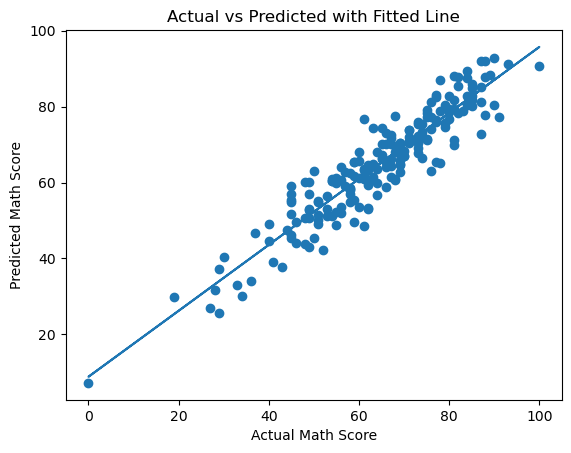

In [33]:
plt.figure()

plt.scatter(y_test, y_pred)

# Best fit line
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m*y_test + b)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted with Fitted Line")
plt.show()

In [29]:

warnings.filterwarnings("ignore")

In [30]:
print("\nEnter Student Details to Predict Math Score\n")

gender = float(input("Enter Gender (0 = Female, 1 = Male): "))
race = float(input("Enter Race/Ethnicity (0–4): "))
parent_edu = float(input("Enter Parental Education (0–5): "))
lunch = float(input("Enter Lunch (0 = Standard, 1 = Free/Reduced): "))
test_prep = float(input("Enter Test Preparation (0 = None, 1 = Completed): "))
reading = float(input("Enter Reading Score: "))
writing = float(input("Enter Writing Score: "))

# Create input array
user_input = [[gender, race, parent_edu, lunch, test_prep, reading, writing]]

# Scale input
user_input_scaled = scaler.transform(user_input)


# Polynomial transform
user_input_poly = poly.transform(user_input_scaled)

# Predict
prediction = model.predict(user_input_poly)

print("\nPredicted Math Score =", round(prediction[0], 2))


Enter Student Details to Predict Math Score



Enter Gender (0 = Female, 1 = Male):  1
Enter Race/Ethnicity (0–4):  2
Enter Parental Education (0–5):  5
Enter Lunch (0 = Standard, 1 = Free/Reduced):  1
Enter Test Preparation (0 = None, 1 = Completed):  1
Enter Reading Score:  2.3
Enter Writing Score:  2.1



Predicted Math Score = 21.11
